# 📊 Phase 02 | Predictive Analytics & Explainable AI (XAI) Engine
# 📊 Fase 02 | Analítica Predictiva y Motor de IA Explicable (XAI)

> **🎯 Objective / Objetivo:** Transition from historical diagnosis to forward-looking decision intelligence.  
> **⚙️ Core Stack / Tecnologías:** `XGBoost Regressor`, `Game Theory (SHAP)`, `Scikit-Learn`

**🇬🇧 EN:** This phase deploys a high-fidelity predictive engine designed to forecast weekly retail demand across dynamic operational conditions. To eliminate the "black-box" nature of advanced tree ensembles and ensure trust among business stakeholders, we implement **SHAP (SHapley Additive exPlanations)**. This game-theoretic approach decomposes complex model outputs into interpretable, actionable drivers, allowing us to quantify the exact marginal contribution of each variable (e.g., store footprint, seasonality, macroeconomics) on final revenue.

**🇲🇽 ES:** Esta fase despliega un motor predictivo de alta fidelidad diseñado para pronosticar la demanda minorista bajo condiciones operativas dinámicas. Para eliminar la naturaleza de "caja negra" de los ensambles de árboles avanzados y garantizar la confianza de los *stakeholders* del negocio, implementamos **SHAP (SHapley Additive exPlanations)**. Este enfoque basado en teoría de juegos descompone las salidas complejas del modelo en impulsores interpretables y accionables, permitiendo cuantificar la contribución marginal exacta de cada variable (ej. tamaño de tienda, estacionalidad, macroeconomía) sobre los ingresos finales.

In [3]:
# ==============================================================================
# 00 | ENVIRONMENT SETUP & KERNEL CONFIGURATION
# 00 | CONFIGURACIÓN DEL ENTORNO Y DEL KERNEL
# ==============================================================================
# 🇬🇧 EN: Standardizing the execution environment and loading dependencies.
# 🇲🇽 ES: Estandarizando el entorno de ejecución y cargando dependencias.

# 1. System & MLOps Configuration / Sistema y Configuración
import warnings
warnings.filterwarnings('ignore') # Suppress non-critical execution warnings

# 2. Core Data Manipulation / Manipulación de Datos Core
import pandas as pd
import numpy as np

# 3. Machine Learning & Explainability (XAI) / Machine Learning y Explicabilidad
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 4. Visualization & Reporting Suite / Suite de Visualización y Reporteo
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 5. Global Aesthetic Blueprint / Plantilla Estética Global
# 🇬🇧 EN: Setting a clean, corporate style for all downstream plots
# 🇲🇽 ES: Configurando un estilo limpio y corporativo para todos los gráficos
sns.set_theme(style="white", palette="muted")
plt.rcParams.update({
    'figure.autolayout': True, 
    'axes.titlesize': 14, 
    'axes.titleweight': 'bold'
})

print("✅ [SYSTEM] Dependencies loaded successfully. Virtual environment optimized.")
print("✅ [SISTEMA] Dependencias cargadas con éxito. Entorno virtual optimizado.")

✅ [SYSTEM] Dependencies loaded successfully. Virtual environment optimized.
✅ [SISTEMA] Dependencias cargadas con éxito. Entorno virtual optimizado.


In [4]:
# ==============================================================================
# 01 | DATA INGESTION & FEATURE ENCODING PIPELINE
# 01 | PIPELINE DE INGESTA DE DATOS Y CODIFICACIÓN DE CARACTERÍSTICAS
# ==============================================================================
print("⏳ [SYSTEM] Initiating data ingestion protocol... / Iniciando protocolo de ingesta...")

# Load the curated dataset from Phase 1 / Cargar el dataset estructurado de la Fase 1
df = pd.read_csv('../data/processed/retail_data_processed.csv')

# ------------------------------------------------------------------------------
# ALGORITHMIC PREPROCESSING / PREPROCESAMIENTO ALGORÍTMICO
# Optimizing data structures for tree-based estimators (XGBoost)
# ------------------------------------------------------------------------------

# 1. Temporal Dimensionality Reduction (Time-series already decomposed in EDA)
# 1. Reducción de Dimensionalidad Temporal (Serie de tiempo descompuesta en EDA)
df = df.drop(columns=['Date'])

# 2. Boolean & Categorical Encoding (One-Hot Encoding to prevent ordinal bias)
# 2. Codificación Booleana y Categórica (One-Hot Encoding para evitar sesgos ordinales)
df['IsHoliday'] = df['IsHoliday'].astype(int)
df = pd.get_dummies(df, columns=['Type'], drop_first=True)

# 3. Target Variable Isolation
# 3. Aislamiento de la Variable Objetivo
X = df.drop(columns=['Weekly_Sales']) # Feature Matrix / Matriz de Características
y = df['Weekly_Sales']                # Target Vector / Vector Objetivo

print(f"✅ [SUCCESS] Feature Matrix engineered. Shape: {X.shape}")
print(f"✅ [ÉXITO] Matriz de características procesada. Dimensión: {X.shape}")

⏳ [SYSTEM] Initiating data ingestion protocol... / Iniciando protocolo de ingesta...
✅ [SUCCESS] Feature Matrix engineered. Shape: (420212, 18)
✅ [ÉXITO] Matriz de características procesada. Dimensión: (420212, 18)


In [5]:
# ==============================================================================
# 02 | DATA PARTITIONING STRATEGY
# 02 | ESTRATEGIA DE PARTICIÓN DE DATOS
# ==============================================================================
# 🇬🇧 EN: Isolating a hold-out test set (20%) to evaluate out-of-sample model generalizability.
# 🇲🇽 ES: Aislando un conjunto de prueba (20%) para evaluar la capacidad de generalización del modelo.

print("⏳ [SYSTEM] Partitioning feature space into training and validation environments...")

# We maintain a fixed random state to ensure deterministic reproducibility
# Mantenemos una semilla aleatoria fija para asegurar reproducibilidad determinista
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# Using formatting (:,) to display numbers with comma separators for readability
print(f"✅ [SUCCESS] Training cohort: {X_train.shape[0]:,} records.")
print(f"✅ [SUCCESS] Hold-out / Test cohort: {X_test.shape[0]:,} records.")

⏳ [SYSTEM] Partitioning feature space into training and validation environments...
✅ [SUCCESS] Training cohort: 336,169 records.
✅ [SUCCESS] Hold-out / Test cohort: 84,043 records.


In [6]:
# ==============================================================================
# 03 | PREDICTIVE ENGINE CALIBRATION (XGBOOST)
# 03 | CALIBRACIÓN DEL MOTOR PREDICTIVO (XGBOOST)
# ==============================================================================
# 🇬🇧 EN: Deploying a scalable tree boosting system optimized for regression tasks.
# 🇲🇽 ES: Desplegando un sistema escalable de boosting de árboles optimizado para regresión.

print("⏳ [SYSTEM] Instantiating Gradient Boosting architecture...")

# Hyperparameter configuration based on retail industry baseline standards
# Configuración de hiperparámetros basada en estándares base de la industria retail
xgb_model = xgb.XGBRegressor(
    n_estimators=150,     # Number of sequential trees / Número de árboles secuenciales
    learning_rate=0.1,    # Step size shrinkage / Reducción del tamaño de paso
    max_depth=6,          # Maximum tree depth / Profundidad máxima del árbol
    random_state=42,      # Ensures deterministic results / Asegura resultados deterministas
    n_jobs=-1             # Parallel processing optimization / Optimización de procesamiento paralelo
)

print("⏳ [SYSTEM] Commencing distributed model training. This may take a moment...")
print("⏳ [SISTEMA] Iniciando entrenamiento distribuido del modelo. Esto puede tomar un momento...")

# Fitting the model to the training cohort
# Ajustando el modelo a la cohorte de entrenamiento
xgb_model.fit(X_train, y_train)

print("✅ [SUCCESS] XGBoost Regression Engine calibrated successfully.")
print("✅ [ÉXITO] Motor de Regresión XGBoost calibrado con éxito.")
print("✅ Model trained successfully! / ¡Modelo entrenado con éxito!")

⏳ [SYSTEM] Instantiating Gradient Boosting architecture...
⏳ [SYSTEM] Commencing distributed model training. This may take a moment...
⏳ [SISTEMA] Iniciando entrenamiento distribuido del modelo. Esto puede tomar un momento...
✅ [SUCCESS] XGBoost Regression Engine calibrated successfully.
✅ [ÉXITO] Motor de Regresión XGBoost calibrado con éxito.
✅ Model trained successfully! / ¡Modelo entrenado con éxito!


⏳ [SYSTEM] Computing performance metrics against hold-out set...

 📊 PREDICTIVE PERFORMANCE REPORT / REPORTE DE RENDIMIENTO
 🎯 R-Squared (R²):           0.9187 (91.87% Variance Explained)
 📉 Mean Absolute Error:      $3,556.25
 📉 Root Mean Squared Error:  $6,443.26

⏳ [SYSTEM] Rendering diagnostic scatter plot...


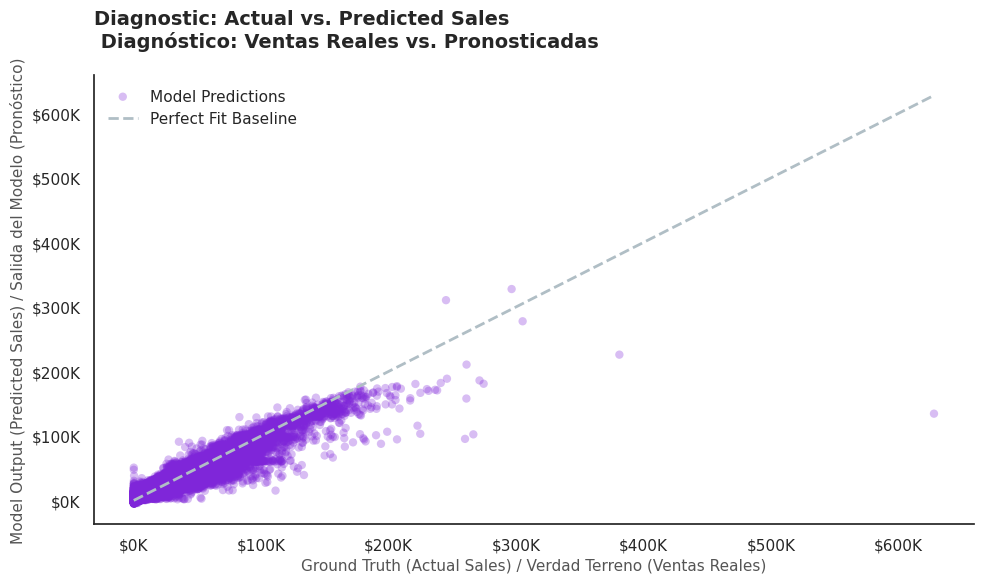

✅ [SUCCESS] Diagnostic visualizations exported to '../reports/figures/'


In [7]:
# ==============================================================================
# 04 | MODEL EVALUATION & ERROR DIAGNOSTICS
# 04 | EVALUACIÓN DEL MODELO Y DIAGNÓSTICO DE ERRORES
# ==============================================================================
# 🇬🇧 EN: Quantifying model accuracy and visualizing prediction variance.
# 🇲🇽 ES: Cuantificando la precisión del modelo y visualizando la varianza de predicción.

print("⏳ [SYSTEM] Computing performance metrics against hold-out set...")

# 1. Generate predictions / Generar predicciones
y_pred = xgb_model.predict(X_test)

# 2. Calculate Evaluation Metrics / Calcular Métricas de Evaluación
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# 3. Executive Summary Printout / Impresión de Resumen Ejecutivo
print("\n" + "="*50)
print(" 📊 PREDICTIVE PERFORMANCE REPORT / REPORTE DE RENDIMIENTO")
print("="*50)
print(f" 🎯 R-Squared (R²):           {r2:.4f} ({(r2*100):.2f}% Variance Explained)")
print(f" 📉 Mean Absolute Error:      ${mae:,.2f}")
print(f" 📉 Root Mean Squared Error:  ${rmse:,.2f}")
print("="*50 + "\n")

# 4. Visual Diagnostics / Diagnóstico Visual
print("⏳ [SYSTEM] Rendering diagnostic scatter plot...")

plt.figure(figsize=(10, 6))

# Scatter plot usando nuestra paleta análoga (Morado: #7F26D9 con transparencia)
plt.scatter(y_test, y_pred, alpha=0.3, color='#7F26D9', edgecolors='none', label='Model Predictions')

# Línea base de "Ajuste Perfecto" (Gris Neutro: #B0BEC5)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], color='#B0BEC5', linestyle='--', linewidth=2, label='Perfect Fit Baseline')

# Títulos y formato estético
plt.title('Diagnostic: Actual vs. Predicted Sales \n Diagnóstico: Ventas Reales vs. Pronosticadas', 
          fontsize=14, fontweight='bold', pad=20, loc='left')

plt.xlabel('Ground Truth (Actual Sales) / Verdad Terreno (Ventas Reales)', fontsize=11, color='#555555')
plt.ylabel('Model Output (Predicted Sales) / Salida del Modelo (Pronóstico)', fontsize=11, color='#555555')

# Formato de ejes en Miles (K)
formatter = ticker.FuncFormatter(lambda x, pos: f'${x*1e-3:,.0f}K')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# Limpieza visual
sns.despine()
plt.legend(loc='upper left', frameon=False)
plt.tight_layout()

# 💾 Exportar gráfica automáticamente
plt.savefig("../reports/figures/02_actual_vs_predicted.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ [SUCCESS] Diagnostic visualizations exported to '../reports/figures/'")

⏳ [SYSTEM] Initializing SHAP TreeExplainer module...
⏳ [SYSTEM] Computing Shapley additive values (Bypassing float-conversion micro-variances)...
⏳ [SYSTEM] Rendering SHAP Beeswarm topology...


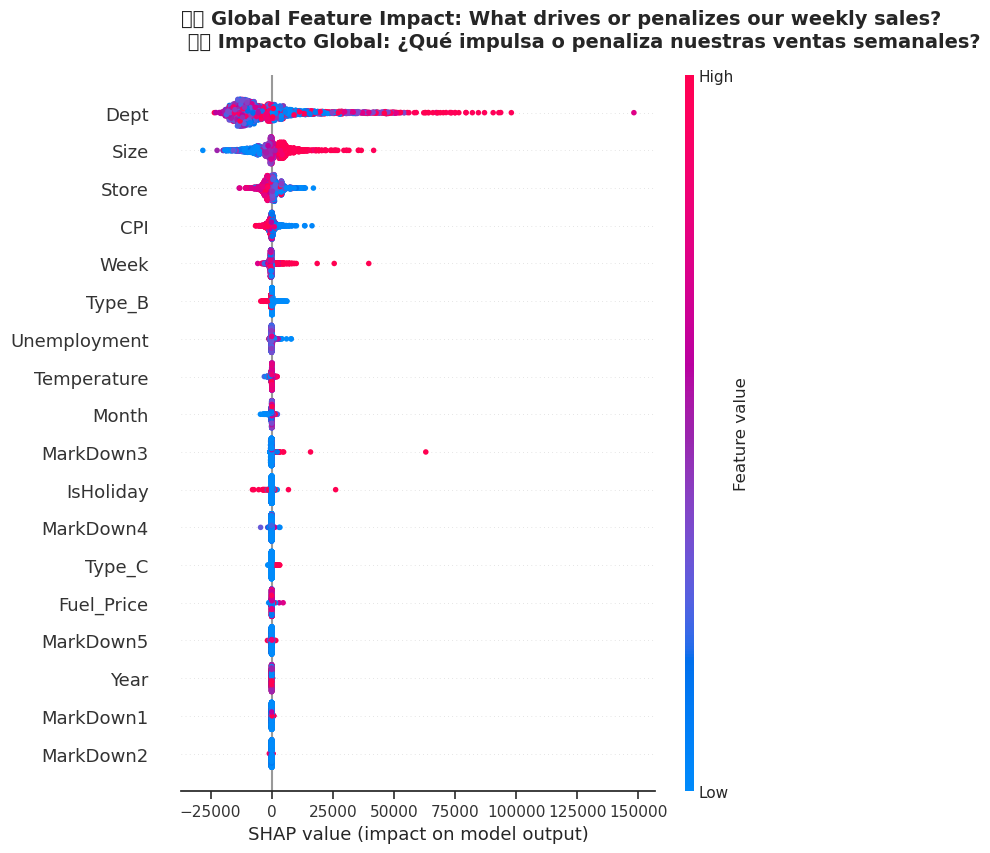

✅ [SUCCESS] XAI visualizations exported to '../reports/figures/'
✅ [SUCCESS] Predictive Modeling Phase Complete. Ready for Prescriptive Analytics (Phase 3).


In [8]:
# ==============================================================================
# 05 | EXPLAINABLE AI (XAI) & DECISION INTELLIGENCE
# 05 | IA EXPLICABLE (XAI) E INTELIGENCIA DE DECISIONES
# ==============================================================================
# 🇬🇧 EN: Deconstructing the "black box" using SHAP (Game Theory) to extract business drivers.
# 🇲🇽 ES: Deconstruyendo la "caja negra" usando SHAP (Teoría de Juegos) para extraer impulsores de negocio.

print("⏳ [SYSTEM] Initializing SHAP TreeExplainer module...")

# 1. Instantiate Explainer / Instanciar el Explicador
explainer = shap.TreeExplainer(xgb_model)

# 2. Optimize computation memory / Optimizar memoria de cómputo
# Sampling 2,500 records is statistically sufficient to extract global feature importance
X_test_sample = X_test.sample(n=2500, random_state=42)

print("⏳ [SYSTEM] Computing Shapley additive values (Bypassing float-conversion micro-variances)...")

# Calculating SHAP values (check_additivity=False resolves the float32 vs float64 rounding conflict)
shap_values = explainer.shap_values(X_test_sample, check_additivity=False)

# 3. Render Executive SHAP Summary / Generar Resumen Ejecutivo SHAP
print("⏳ [SYSTEM] Rendering SHAP Beeswarm topology...")

plt.figure(figsize=(10, 6))

# Default SHAP colormap is preserved as it's the industry standard for XAI
shap.summary_plot(shap_values, X_test_sample, show=False)

# Executive Titling / Titulación Ejecutiva
plt.title('🇬🇧 Global Feature Impact: What drives or penalizes our weekly sales? \n 🇲🇽 Impacto Global: ¿Qué impulsa o penaliza nuestras ventas semanales?', 
          fontsize=14, fontweight='bold', pad=20, loc='left')

plt.tight_layout()

# 💾 Exportar gráfica automáticamente
plt.savefig("../reports/figures/02_shap_feature_importance.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ [SUCCESS] XAI visualizations exported to '../reports/figures/'")
print("✅ [SUCCESS] Predictive Modeling Phase Complete. Ready for Prescriptive Analytics (Phase 3).")

## 👤 Applied Data Scientist & Researcher / Científico de Datos Aplicado e Investigador

**Pablo Alberto Santana Flores**  
*Chemical Engineer | PhD in Marine Sciences | Decision Intelligence*  

> **🇬🇧 EN:** Thank you for reviewing the Predictive Analytics phase. The exported diagnostic plots (`/reports/figures/`) provide a transparent view of the model's reliability. Next, we will transition to **Phase 3: Prescriptive Analytics**, where we will use linear programming (`PuLP`) to optimize inventory and maximize profit. Feel free to connect on LinkedIn to discuss the technical architecture of this project.  
> 
> **🇲🇽 ES:** Gracias por revisar la fase de Analítica Predictiva. Los gráficos de diagnóstico exportados ofrecen una vista transparente de la confiabilidad del modelo. A continuación, pasaremos a la **Fase 3: Analítica Prescriptiva**, donde usaremos programación lineal (`PuLP`) para optimizar el inventario y maximizar ganancias. Siéntete libre de conectar en LinkedIn para discutir la arquitectura técnica de este proyecto.

*   **LinkedIn:** [linkedin.com/in/pablo-santana-mx](https://mx.linkedin.com/in/pablo-santana-mx)
*   **GitHub:** [github.com/Pablo-Santana-MX](https://github.com/Pablo-Santana-MX)